<a href="https://colab.research.google.com/github/brendanperez/PHY386/blob/brendanperez%3Dhw6/2026/HW/brendanperez/HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/HW/HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6: Classifying Celestial Objects with Neural Networks (42 pts)

## Learning Outcomes

- Understand how **neural networks** work: layers, activation functions, and training via backpropagation
- Use **astroquery** to programmatically retrieve data from the Sloan Digital Sky Survey
- Train an `MLPClassifier` (scikit-learn) to classify **stars, galaxies, and quasars** from SDSS photometric data
- Evaluate classifiers using **accuracy, confusion matrices, and loss curves**
- Compare neural network performance to **Decision Tree, KNN, and Random Forest** classifiers from HW5
- Explore how **network architecture** (number and size of hidden layers) affects performance
- Create **publication-quality plots** of model comparisons and evaluation metrics
- Submit homework via **fork and pull request**

## Development Environment

You have two options for working on this homework:

### Option A: GitHub Codespaces (recommended)

> **If you have an existing Codespace from HW5**: the environment now includes `astroquery` which wasn't in the HW5 setup. Either create a **new** Codespace, or run `pip install -r requirements/requirements_HW2026.txt` in your existing Codespace terminal.

1. **Fork the repository**: Go to [github.com/ubsuny/PHY386](https://github.com/ubsuny/PHY386) → click **"Fork"**
2. **Sync your fork**: On your fork's page, click **"Sync fork"** → **"Update branch"**
3. **Open a Codespace**: Green **"Code"** button → **"Codespaces"** tab → **"Create codespace on Homework2026"**
4. **Create your branch**: In the terminal: `git checkout -b yourname-hw6`
5. Work on `2026/HW/yourname/HW6.ipynb` using the built-in Jupyter extension

### Option B: Google Colab

Click the **"Open in Colab"** badge at the top of this notebook. When done, use **File → Save a copy to GitHub** to push to your fork.

> **Colab users**: you may need to install astroquery first. Run this in a cell before the worked example:
> ```python
> !pip install astroquery
> ```

---

**Either way, you must submit via the fork workflow** (see Submission section at the end).

## Background

### The SDSS Photometric System

The [Sloan Digital Sky Survey (SDSS)](https://www.sdss.org/) is one of the most influential astronomical surveys ever conducted. It measures the brightness of celestial objects through five optical filters:

| Filter | Wavelength (nm) | Region |
|--------|----------------|--------|
| u | 355 | Ultraviolet |
| g | 477 | Green |
| r | 623 | Red |
| i | 763 | Near-infrared |
| z | 913 | Near-infrared |

Each filter records a **magnitude** — a logarithmic measure of brightness. The differences between magnitudes in different filters (called **colors**, e.g., $u - g$, $g - r$) encode the spectral shape of the object, which is related to its physical nature.

The dataset also includes **redshift** — the Doppler shift of spectral lines due to the expansion of the universe. Nearby stars have redshift $\approx 0$, nearby galaxies have redshift $\sim 0.01$–$0.3$, and quasars can have redshift $> 1$.

### Three Classes of Celestial Objects

- **Stars**: Point-like sources in our galaxy. Low redshift, smooth spectral energy distributions.
- **Galaxies**: Extended collections of billions of stars. Moderate redshift. Diverse photometric profiles depending on galaxy type (spiral, elliptical, irregular).
- **Quasars (QSO)**: Extremely luminous active galactic nuclei powered by supermassive black holes. Very high redshift. Unusual photometric colors that can mimic stars in some filters.

### Querying Astronomical Databases with astroquery

In research, you rarely start with a CSV file — you query data directly from astronomical databases. The Python library [astroquery](https://astroquery.readthedocs.io/) provides a unified interface to dozens of astronomical archives, including SDSS, NASA's NED, SIMBAD, and more.

The SDSS database stores photometric and spectroscopic measurements of hundreds of millions of objects. You can query it using **SQL** (Structured Query Language) — the standard language for interacting with databases.

#### SQL Basics for Astronomers

An SQL query has three main parts:

```sql
SELECT columns       -- what data you want
FROM table           -- which database table
WHERE conditions     -- filtering criteria
```

For example, to get photometric magnitudes and classifications from the SDSS spectroscopic catalog:

```sql
SELECT TOP 100
    p.u, p.g, p.r, p.i, p.z,
    s.z AS redshift, s.class AS object_class
FROM
    PhotoObj AS p
    JOIN SpecObj AS s ON s.bestObjID = p.objID
WHERE
    s.zWarning = 0
    AND p.clean = 1
```

This query:
- Selects magnitudes (`u, g, r, i, z`) from the photometry table (`PhotoObj`)
- Joins with the spectroscopy table (`SpecObj`) to get redshift and classification
- Filters for reliable redshifts (`zWarning = 0`) and clean photometry (`clean = 1`)
- `TOP 100` limits results to 100 rows (useful for testing before running large queries)

#### Using astroquery in Python

```python
from astroquery.sdss import SDSS

query = """
SELECT TOP 100
    p.u, p.g, p.r, p.i, p.z,
    s.z AS redshift, s.class AS object_class
FROM PhotoObj AS p
    JOIN SpecObj AS s ON s.bestObjID = p.objID
WHERE s.zWarning = 0 AND p.clean = 1
"""
result = SDSS.query_sql(query)
df = result.to_pandas()
```

The result is an Astropy `Table` that you can convert to a pandas DataFrame for familiar data manipulation.

### Neural Networks

In HW5, you trained **Decision Trees**, **KNN**, and **Random Forests** to classify stars. These are powerful methods, but they have limitations:

- **Decision Trees** can only make axis-aligned splits ("is temperature > 8000?"). They can't learn diagonal or curved decision boundaries.
- **KNN** relies on local distance — it doesn't learn a global model of the data.
- **Random Forests** combine many trees, which helps, but each individual tree still makes axis-aligned splits.

**Neural networks** take a fundamentally different approach. They learn a chain of nonlinear transformations that map input features to output classes.

#### From Least-Squares Fitting to Neural Networks

You've already done something conceptually similar to what a neural network does — in earlier homework, you fit curves to data using least-squares minimization. The connection is deeper than you might think:

**Least-squares fitting**: You choose a model (e.g., $y = mx + b$), define an error function (sum of squared residuals), and find the parameters ($m$, $b$) that minimize it. For a linear model, there's a closed-form solution (the normal equations).

**Neural network training**: You choose a model (a network architecture), define a loss function (e.g., cross-entropy for classification), and find the parameters (weights and biases) that minimize it. There's no closed-form solution — instead, the network uses **gradient descent**, iteratively adjusting parameters in the direction that reduces the loss.

The key difference is **capacity**: a linear fit has 2 parameters and can only learn a straight line. A neural network with two hidden layers of 64 and 32 neurons has thousands of parameters and can learn arbitrarily complex functions. The training principle — minimize an error/loss by adjusting parameters — is the same.

| | Least-Squares Fit | Neural Network |
|---|---|---|
| Model | $y = mx + b$ | Layers of neurons |
| Parameters | $m$, $b$ (2 params) | Weights & biases (thousands) |
| Error/Loss | Sum of squared residuals | Cross-entropy (classification) |
| Optimization | Normal equations (exact) | Gradient descent (iterative) |
| Capacity | Linear relationships only | Any function (with enough neurons) |

#### The Perceptron: A Single Artificial Neuron

The basic building block is the **perceptron** — a function that takes a weighted sum of inputs, adds a bias, and applies a nonlinear **activation function**:

$$z = \sigma\left(\sum_{i=1}^{n} w_i x_i + b\right)$$

where $x_i$ are the input features, $w_i$ are learned weights, $b$ is a bias term, and $\sigma$ is an activation function like the **ReLU** (Rectified Linear Unit):

$$\text{ReLU}(z) = \max(0, z)$$

A single neuron can only learn a linear boundary. But when we stack neurons into **layers**, the network can learn arbitrarily complex, nonlinear decision boundaries.

#### Multi-Layer Perceptron (MLP)

An MLP has:
- An **input layer**: one neuron per feature (for SDSS data: 6 inputs for u, g, r, i, z, redshift)
- One or more **hidden layers**: each neuron computes a weighted sum of the previous layer's outputs, applies an activation function
- An **output layer**: one neuron per class (STAR, GALAXY, QSO), with a softmax function that converts outputs to probabilities

```
Input (6)  →  Hidden Layer 1 (64 neurons)  →  Hidden Layer 2 (32 neurons)  →  Output (3 classes)
  u              ●  ●  ●  ...  ●                  ●  ●  ...  ●                  STAR
  g              ●  ●  ●  ...  ●                  ●  ●  ...  ●                  GALAXY
  r              ●  ●  ●  ...  ●                  ●  ●  ...  ●                  QSO
  i              ●  ●  ●  ...  ●                  ●  ●  ...  ●
  z              ●  ●  ●  ...  ●                  ●  ●  ...  ●
  redshift       ●  ●  ●  ...  ●                  ●  ●  ...  ●
```

#### Training: Backpropagation

The network learns by adjusting its weights to minimize a **loss function** (how wrong the predictions are). The algorithm:

1. **Forward pass**: feed data through the network, get predictions
2. **Compute loss**: measure how far predictions are from true labels
3. **Backward pass**: compute how each weight contributed to the error (via the chain rule of calculus)
4. **Update weights**: adjust weights to reduce the error

This process repeats for many **iterations** (epochs) until the loss converges.

#### scikit-learn's MLPClassifier

scikit-learn provides `MLPClassifier` — a neural network with the **same `fit`/`predict` API** you already know from HW5:

```python
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
```

The `hidden_layer_sizes` parameter controls the architecture: `(64, 32)` means two hidden layers with 64 and 32 neurons respectively.

---

## Worked Example: Querying SDSS and Training a Neural Network

### Fetching Data with astroquery

Let's query the SDSS database for a sample of objects with photometric magnitudes and spectral classifications. This is how the dataset `data/sdss_sample.csv` was created.

In [168]:
!pip install astroquery

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Publication-quality plot settings ---
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.figsize': (6, 4),
})

In [170]:
from astroquery.sdss import SDSS

def fetch_sdss_sample(n_per_class: int = 50) -> pd.DataFrame:
    """Fetch a balanced sample of stars, galaxies, and quasars from SDSS.

    Queries the SDSS SkyServer database using SQL via astroquery.
    Returns photometric magnitudes (u, g, r, i, z), redshift, and
    the spectral classification for each object.

    Parameters
    ----------
    n_per_class : int
        Number of objects to fetch per class (STAR, GALAXY, QSO).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns u, g, r, i, z, redshift, object_class.
    """
    query = f"""
    SELECT TOP {n_per_class}
        p.u, p.g, p.r, p.i, p.z,
        s.z AS redshift, s.class AS object_class
    FROM PhotoObj AS p
        JOIN SpecObj AS s ON s.bestObjID = p.objID
    WHERE
        s.class = 'STAR'
        AND s.zWarning = 0
        AND p.clean = 1
        AND p.u BETWEEN 15 AND 25
        AND p.g BETWEEN 15 AND 25
    """
    stars = SDSS.query_sql(query).to_pandas()

    query = f"""
    SELECT TOP {n_per_class}
        p.u, p.g, p.r, p.i, p.z,
        s.z AS redshift, s.class AS object_class
    FROM PhotoObj AS p
        JOIN SpecObj AS s ON s.bestObjID = p.objID
    WHERE
        s.class = 'GALAXY'
        AND s.zWarning = 0
        AND p.clean = 1
        AND p.u BETWEEN 15 AND 25
        AND p.g BETWEEN 15 AND 25
    """
    galaxies = SDSS.query_sql(query).to_pandas()

    query = f"""
    SELECT TOP {n_per_class}
        p.u, p.g, p.r, p.i, p.z,
        s.z AS redshift, s.class AS object_class
    FROM PhotoObj AS p
        JOIN SpecObj AS s ON s.bestObjID = p.objID
    WHERE
        s.class = 'QSO'
        AND s.zWarning = 0
        AND p.clean = 1
        AND p.u BETWEEN 15 AND 25
        AND p.g BETWEEN 15 AND 25
    """
    quasars = SDSS.query_sql(query).to_pandas()

    df = pd.concat([stars, galaxies, quasars], ignore_index=True)
    print(f"Fetched {len(df)} objects: {len(stars)} stars, "
          f"{len(galaxies)} galaxies, {len(quasars)} quasars")
    return df


# Fetch a small demo sample (50 per class)
df_demo = fetch_sdss_sample(n_per_class=50)
print(f"\nColumns: {list(df_demo.columns)}")
print(f"\nClass distribution:\n{df_demo['object_class'].value_counts()}")

Fetched 150 objects: 50 stars, 50 galaxies, 50 quasars

Columns: ['u', 'g', 'r', 'i', 'z', 'redshift', 'object_class']

Class distribution:
object_class
STAR      50
GALAXY    50
QSO       50
Name: count, dtype: int64


### From Least Squares to Neural Networks: A Concrete Example

To see the connection between curve fitting and neural networks, let's fit noisy data with polynomials of increasing degree alongside neural networks of increasing size. This illustrates **model capacity** — how complex a pattern the model can learn.

Just like polynomials, neural networks can **underfit** (too simple), **fit well**, or **overfit** (too complex):

| | Polynomial | Neural Network |
|---|---|---|
| Underfit | Too few terms (degree 1) | Too few neurons |
| Good fit | Right complexity (degree 3) | Appropriate architecture |
| Overfit | Too many terms (degree 15) | Too many neurons, no regularization |

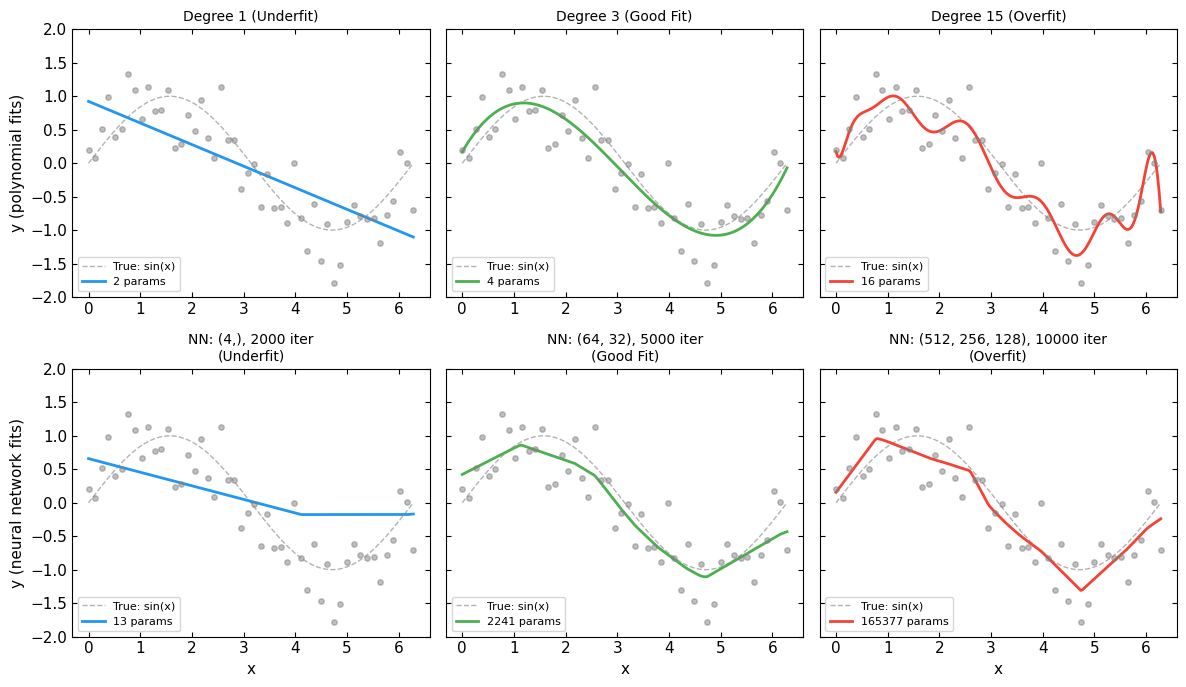

Top row:    Polynomial fits — capacity controlled by the degree.
Bottom row: Neural network fits — capacity controlled by network size.

• Underfit: too few neurons (4) can only learn a crude approximation.
• Good fit: (64, 32) with moderate training captures the shape well.
• Overfit:  a huge network (512, 256, 128) with no regularization (alpha=0)
  has enough capacity to memorize the noise in the data.


In [171]:
from sklearn.neural_network import MLPRegressor

# Generate noisy sinusoidal data (like a physics measurement)
np.random.seed(42)
x_data = np.linspace(0, 2 * np.pi, 50)
y_data = np.sin(x_data) + 0.4 * np.random.randn(len(x_data))
x_fine = np.linspace(0, 2 * np.pi, 200)

# --- Polynomial fits of increasing degree ---
poly_degrees = [1, 3, 15]
poly_fits = {}
for deg in poly_degrees:
    coeffs = np.polyfit(x_data, y_data, deg)
    poly_fits[deg] = np.polyval(coeffs, x_fine)

# --- Neural network fits: underfit, good, overfit ---
scaler_x = StandardScaler()
X_nn = scaler_x.fit_transform(x_data.reshape(-1, 1))
X_fine_nn = scaler_x.transform(x_fine.reshape(-1, 1))

nn_configs_list = [
    ('NN: (4,), 2000 iter\n(Underfit)', (4,), 2000, 1e-4),
    ('NN: (64, 32), 5000 iter\n(Good Fit)', (64, 32), 5000, 1e-4),
    ('NN: (512, 256, 128), 10000 iter\n(Overfit)', (512, 256, 128), 10000, 0.0),
]
nn_results = []
for label, layers, iters, alpha in nn_configs_list:
    nn = MLPRegressor(hidden_layer_sizes=layers, max_iter=iters,
                       random_state=42, activation='relu', alpha=alpha,
                       learning_rate_init=0.001)
    nn.fit(X_nn, y_data)
    y_pred = nn.predict(X_fine_nn)
    nn_results.append((label, y_pred, nn))

# --- 2x3 figure: top row = polynomials, bottom row = neural networks ---
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)

# Top row: Polynomial fits
poly_configs = [
    (poly_fits[1], 'Degree 1 (Underfit)', '#2196F3', 2),
    (poly_fits[3], 'Degree 3 (Good Fit)', '#4CAF50', 4),
    (poly_fits[15], 'Degree 15 (Overfit)', '#F44336', 16),
]
for ax, (y_fit, title, color, n_p) in zip(axes[0], poly_configs):
    ax.scatter(x_data, y_data, s=15, color='gray', alpha=0.5, zorder=3)
    ax.plot(x_fine, np.sin(x_fine), 'k--', alpha=0.3, linewidth=1, label='True: sin(x)')
    ax.plot(x_fine, y_fit, color=color, linewidth=2, label=f'{n_p} params')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='lower left')
    ax.set_ylim(-2.0, 2.0)

axes[0, 0].set_ylabel('y (polynomial fits)')

# Bottom row: Neural network fits
colors_nn = ['#2196F3', '#4CAF50', '#F44336']
def count_params(nn):
    return sum(c.size for c in nn.coefs_) + sum(b.size for b in nn.intercepts_)

for ax, (label, y_fit, nn), color in zip(axes[1], nn_results, colors_nn):
    ax.scatter(x_data, y_data, s=15, color='gray', alpha=0.5, zorder=3)
    ax.plot(x_fine, np.sin(x_fine), 'k--', alpha=0.3, linewidth=1, label='True: sin(x)')
    ax.plot(x_fine, y_fit, color=color, linewidth=2, label=f'{count_params(nn)} params')
    ax.set_xlabel('x')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8, loc='lower left')
    ax.set_ylim(-2.0, 2.0)

axes[1, 0].set_ylabel('y (neural network fits)')

plt.tight_layout()
plt.show()

print("Top row:    Polynomial fits — capacity controlled by the degree.")
print("Bottom row: Neural network fits — capacity controlled by network size.")
print()
print("• Underfit: too few neurons (4) can only learn a crude approximation.")
print("• Good fit: (64, 32) with moderate training captures the shape well.")
print("• Overfit:  a huge network (512, 256, 128) with no regularization (alpha=0)")
print("  has enough capacity to memorize the noise in the data.")

### Neural Network for Classification: The Moons Dataset

The regression example above shows how neural networks fit continuous data. Now let's see how `MLPClassifier` handles a **classification** task.

The `make_moons` function from scikit-learn generates two interleaving half-circles. The `noise` parameter controls how much scatter is added to the points — this simulates real-world measurement uncertainty. Let's first see what the data looks like at different noise levels:

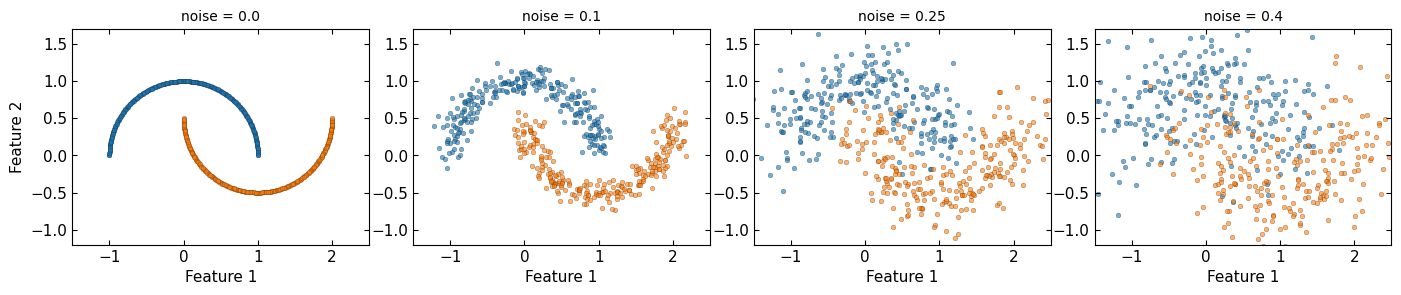

With noise=0, the two half-circles are perfectly separated.
As noise increases, the classes overlap more — making classification harder.
We'll use noise=0.25 (a realistic level of overlap) for the worked example.
The key challenge: the boundary between classes is CURVED, not a straight line.


In [172]:
# Visualize the moons dataset with different noise levels
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
noise_levels = [0.0, 0.1, 0.25, 0.4]
colors = ['#1f77b4', '#ff7f0e']

for ax, noise in zip(axes, noise_levels):
    X, y = make_moons(n_samples=500, noise=noise, random_state=42)
    for label, color in [(0, colors[0]), (1, colors[1])]:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], c=color, s=12, alpha=0.6,
                   edgecolors='k', linewidths=0.2)
    ax.set_title(f'noise = {noise}', fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_aspect('equal')
    ax.set_xlim(-1.5, 2.5)
    ax.set_ylim(-1.2, 1.7)

axes[0].set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

print("With noise=0, the two half-circles are perfectly separated.")
print("As noise increases, the classes overlap more — making classification harder.")
print("We'll use noise=0.25 (a realistic level of overlap) for the worked example.")
print("The key challenge: the boundary between classes is CURVED, not a straight line.")

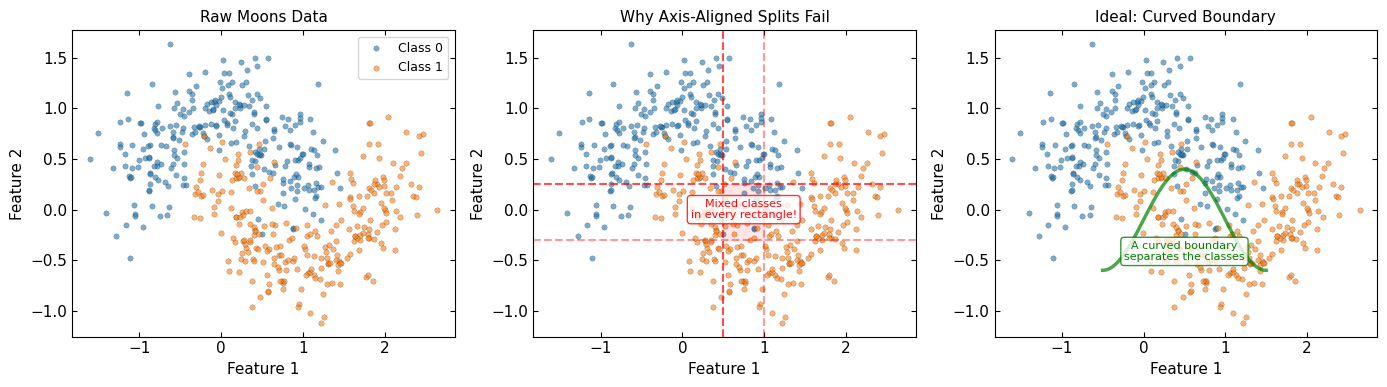

Decision Trees split the feature space with horizontal and vertical lines.
No matter how many splits you make, rectangles cannot cleanly separate curves.
Neural networks learn smooth, curved decision boundaries — exactly what we need.


In [173]:
# First, visualize the raw moons data and the axis-aligned splitting problem
X_raw, y_raw = make_moons(n_samples=500, noise=0.25, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Raw data
ax = axes[0]
for label, name, color in [(0, 'Class 0', '#1f77b4'), (1, 'Class 1', '#ff7f0e')]:
    mask = y_raw == label
    ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c=color, s=15, alpha=0.6,
               edgecolors='k', linewidths=0.2, label=name)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Raw Moons Data')
ax.legend(fontsize=9)

# Panel 2: Show axis-aligned grid to illustrate the Decision Tree problem
ax = axes[1]
for label, color in [(0, '#1f77b4'), (1, '#ff7f0e')]:
    mask = y_raw == label
    ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c=color, s=15, alpha=0.6,
               edgecolors='k', linewidths=0.2)
# Draw axis-aligned splits that a decision tree might try
ax.axhline(y=0.25, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(x=0.5, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axhline(y=-0.3, color='red', linewidth=1.5, linestyle='--', alpha=0.4)
ax.axvline(x=1.0, color='red', linewidth=1.5, linestyle='--', alpha=0.4)
# Shade a rectangle to show the problem
ax.fill_between([0.5, 1.0], -0.3, 0.25, alpha=0.1, color='red')
ax.annotate('Mixed classes\nin every rectangle!', xy=(0.75, 0.0), fontsize=8,
            ha='center', va='center', color='red',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.8))
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Why Axis-Aligned Splits Fail')

# Panel 3: Show the ideal curved boundary
ax = axes[2]
for label, color in [(0, '#1f77b4'), (1, '#ff7f0e')]:
    mask = y_raw == label
    ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c=color, s=15, alpha=0.6,
               edgecolors='k', linewidths=0.2)
# Draw an approximate curved boundary
t = np.linspace(-0.5, 1.5, 100)
curve_y = 0.5 * np.sin(np.pi * t) - 0.1
ax.plot(t, curve_y, 'green', linewidth=2.5, linestyle='-', alpha=0.7)
ax.annotate('A curved boundary\nseparates the classes', xy=(0.5, -0.5), fontsize=8,
            ha='center', color='green',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='green', alpha=0.8))
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Ideal: Curved Boundary')

plt.tight_layout()
plt.show()

print("Decision Trees split the feature space with horizontal and vertical lines.")
print("No matter how many splits you make, rectangles cannot cleanly separate curves.")
print("Neural networks learn smooth, curved decision boundaries — exactly what we need.")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Decision Tree — Train: 1.000, Test: 0.927
Neural Network — Train: 0.951, Test: 0.953


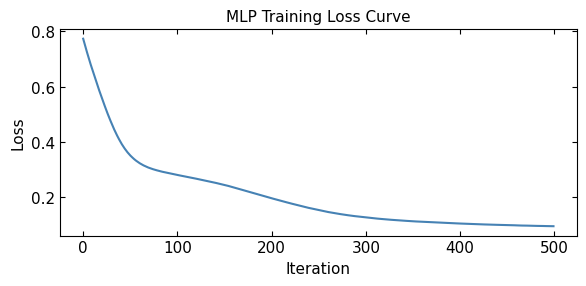

The loss decreases as the network learns the curved boundary.


In [174]:
# Now train classifiers on the moons data and compare decision boundaries
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42
)
scaler_moons = StandardScaler()
X_tr = scaler_moons.fit_transform(X_tr)
X_te = scaler_moons.transform(X_te)

# Train MLP and Decision Tree
mlp_demo = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
mlp_demo.fit(X_tr, y_tr)
dt_demo = DecisionTreeClassifier(random_state=42)
dt_demo.fit(X_tr, y_tr)

print(f"Decision Tree — Train: {dt_demo.score(X_tr, y_tr):.3f}, Test: {dt_demo.score(X_te, y_te):.3f}")
print(f"Neural Network — Train: {mlp_demo.score(X_tr, y_tr):.3f}, Test: {mlp_demo.score(X_te, y_te):.3f}")

# Plot training loss curve
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(mlp_demo.loss_curve_, color='steelblue')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('MLP Training Loss Curve')
plt.tight_layout()
plt.show()
print("The loss decreases as the network learns the curved boundary.")

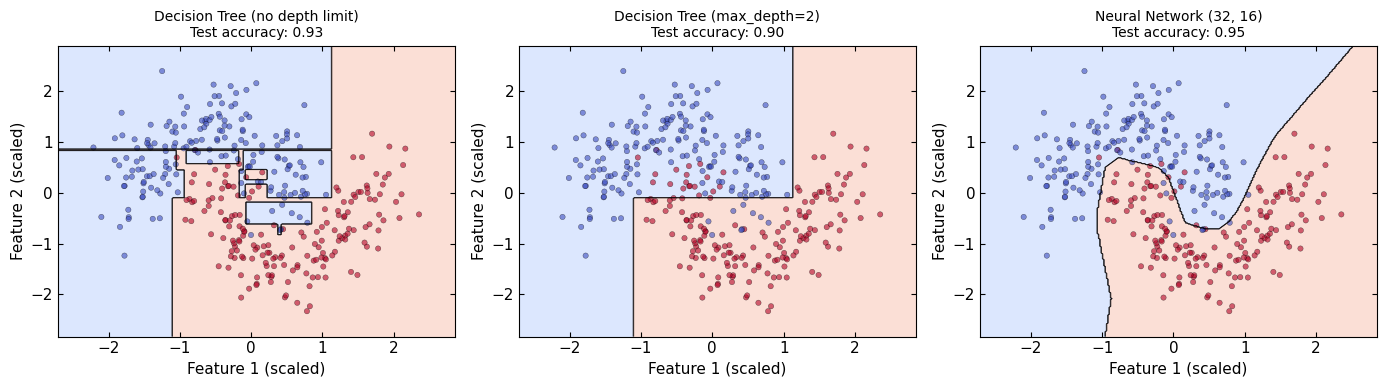

Key observations:
• Decision Trees create jagged, rectangular boundaries — even with more depth.
  With max_depth=2, only a few coarse splits are possible (underfitting).
  Without a depth limit, the tree overfits with many tiny rectangles.
• The Neural Network learns a smooth curve that generalizes better to unseen data.
• This advantage grows with more complex, non-axis-aligned class boundaries.


In [175]:
# Decision boundary comparison: Decision Tree vs Neural Network
# Create mesh grid for decision boundary visualization
x_min, x_max = X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5
y_min, y_max = X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Also train a shallow Decision Tree to show it still makes rectangles
dt_shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_shallow.fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

classifiers = [
    (dt_demo, 'Decision Tree (no depth limit)'),
    (dt_shallow, 'Decision Tree (max_depth=2)'),
    (mlp_demo, 'Neural Network (32, 16)')
]

for ax, (clf, name) in zip(axes, classifiers):
    Z = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm', levels=1)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5, levels=1)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap='coolwarm',
               edgecolors='k', linewidths=0.3, s=15, alpha=0.6)
    acc = clf.score(X_te, y_te)
    ax.set_title(f'{name}\nTest accuracy: {acc:.2f}', fontsize=10)
    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')

plt.tight_layout()
plt.show()

print("Key observations:")
print("• Decision Trees create jagged, rectangular boundaries — even with more depth.")
print("  With max_depth=2, only a few coarse splits are possible (underfitting).")
print("  Without a depth limit, the tree overfits with many tiny rectangles.")
print("• The Neural Network learns a smooth curve that generalizes better to unseen data.")
print("• This advantage grows with more complex, non-axis-aligned class boundaries.")

---

## Part 1: Data Exploration (6 pts)

**Task 1.1 (3 pts):** Load `data/sdss_sample.csv` with pandas. Print `df.shape`, `df.describe()`, and the class distribution using `df['object_class'].value_counts()`. Write a function `load_sdss` that returns the DataFrame.

```python
def load_sdss(filepath: str = 'data/sdss_sample.csv') -> pd.DataFrame:
    """Load the SDSS photometric dataset.

    Parameters
    ----------
    filepath : str
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns u, g, r, i, z, redshift, object_class.
    """
    ...
```

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Publication-quality plot settings ---
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.figsize': (6, 4),
})

In [177]:
# Task 1.1: Your code here
# For Colab, use: pd.read_csv('https://raw.githubusercontent.com/ubsuny/PHY386/Homework2026/2026/HW/data/sdss_sample.csv')
# For Codespaces, use: pd.read_csv('data/sdss_sample.csv')

def load_sdss(filepath: str = 'https://raw.githubusercontent.com/ubsuny/PHY386/Homework2026/2026/HW/data/sdss_sample.csv') -> pd.DataFrame:
    """Load the SDSS photometric dataset.

    Parameters
    ----------
    filepath : str
        Path to the CSV file.

    Returns
    -------
    df_sdss : pd.DataFrame
        DataFrame with columns u, g, r, i, z, redshift, object_class.

    """
    df_sdss = pd.read_csv(filepath)
    return(df_sdss)

In [178]:
df_sdss = load_sdss()
print(df_sdss.shape)
print(df_sdss.describe())
print(df_sdss['object_class'].value_counts())

(2001, 7)
                 u            g            r            i            z  \
count  2001.000000  2001.000000  2001.000000  2001.000000  2001.000000   
mean     21.740440    20.428311    19.672284    19.225192    18.970767   
std       2.250542     2.015313     1.897351     1.817165     1.850000   
min      12.262400    10.511390    10.068540    12.926860    10.225510   
25%      20.121780    18.948990    18.352860    17.985630    17.719020   
50%      21.705690    20.852790    20.176030    19.577250    19.193860   
75%      23.230280    21.859970    21.104330    20.648260    20.381840   
max      27.596990    27.414650    29.571860    22.960380    23.600690   

          redshift  
count  2001.000000  
mean      0.716069  
std       0.912638  
min      -0.005675  
25%       0.000069  
50%       0.399652  
75%       1.153498  
max       6.911286  
object_class
STAR      667
GALAXY    667
QSO       667
Name: count, dtype: int64


**Task 1.2 (3 pts):** Create a **2×2 grid** of scatter plots (`figsize=(10, 8)`) showing pairs of photometric features colored by `object_class`. Suggested pairs:

1. `u` vs. `g`
2. `g` vs. `r`
3. `r` vs. `i`
4. `redshift` vs. `g`

Use three distinct colors (one per class) with a legend. Label axes with filter names. This gives you a visual sense of whether the classes are separable.

*Hint*: You can use `df[df['object_class'] == 'STAR']` to select rows for each class.

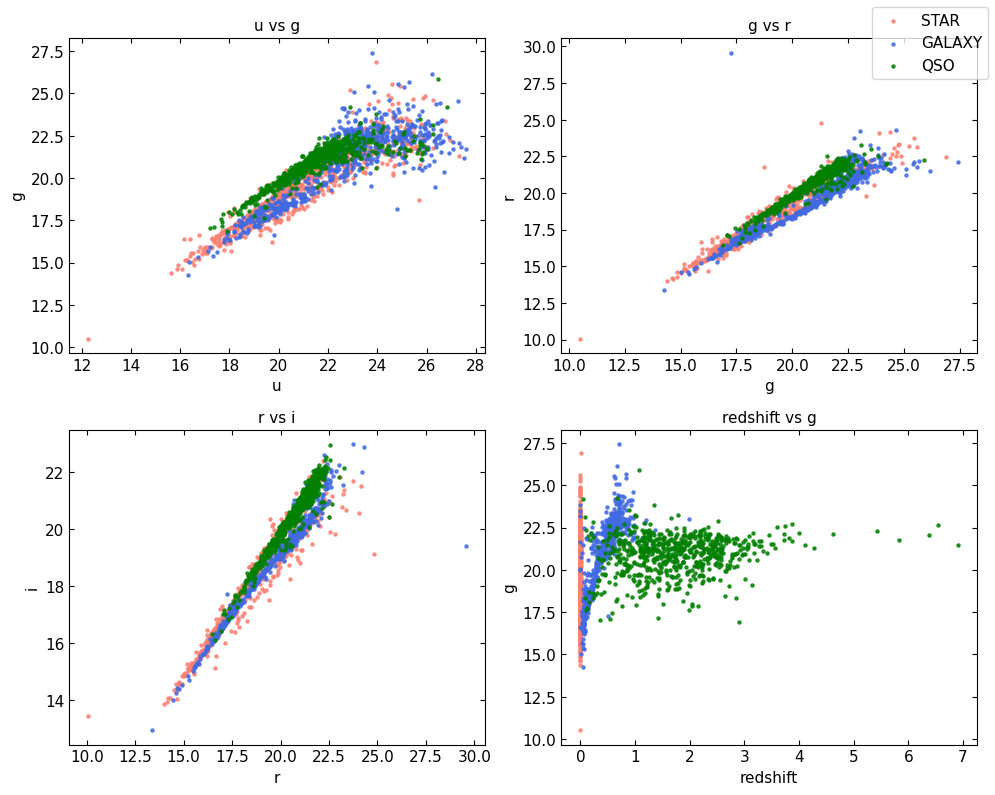

In [179]:
# Task 1.2: Your code here
fig, axes = plt.subplots(2,2, figsize=(10,8))

pairs = [('u','g'),('g','r'),('r','i'),('redshift','g')]
colors = {'STAR' : 'salmon', 'GALAXY': 'royalblue', 'QSO': 'green'}

for ax, (xCol, yCol) in zip(axes.ravel(), pairs):
  for object_class, color in colors.items():
    subset = df_sdss[df_sdss['object_class'] == object_class]
    ax.scatter(subset[xCol], subset[yCol], s=5, c=color, label=object_class, alpha=0.8)
  ax.set_xlabel(xCol)
  ax.set_ylabel(yCol)
  ax.set_title('{} vs {}'.format(xCol, yCol))
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels)
plt.tight_layout()
plt.show()

---

## Part 2: Querying SDSS with astroquery (10 pts)

In the worked example, we fetched a small sample from SDSS. Now you'll write your own query to fetch a **different** dataset — specifically, **brighter objects** in a narrower magnitude range.

**Task 2.1 (4 pts):** Write a function `fetch_bright_sdss` that queries SDSS for objects with $r$-band magnitude between 14 and 19 (brighter than the sample in `sdss_sample.csv`). Fetch 200 objects per class (STAR, GALAXY, QSO).

```python
def fetch_bright_sdss(n_per_class: int = 200) -> pd.DataFrame:
    """Fetch bright SDSS objects with r-band magnitude between 14 and 19.

    Queries the SDSS SkyServer for stars, galaxies, and quasars with
    clean photometry and reliable redshifts.

    Parameters
    ----------
    n_per_class : int
        Number of objects to fetch per class.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns u, g, r, i, z, redshift, object_class.
    """
    ...
```

Print `df.shape`, the class distribution, and `df.describe()` for the result.

*Hint*: Adapt the worked example query. Change the magnitude filter to `p.r BETWEEN 14 AND 19` and increase `TOP` to 200.

In [180]:
# Task 2.1: Your code here
def fetch_bright_sdss(n_per_class: int = 200) -> pd.DataFrame:
    """Fetch bright SDSS objects with r-band magnitude between 14 and 19.

    Queries the SDSS SkyServer for stars, galaxies, and quasars with
    clean photometry and reliable redshifts.

    Parameters
    ----------
    n_per_class : int
        Number of objects to fetch per class.

    Returns
    -------
    df_bright_sdss : pd.DataFrame
        DataFrame with columns u, g, r, i, z, redshift, object_class.
    """

    from astroquery.sdss import SDSS

    object_classes = ['STAR', 'GALAXY', 'QSO']
    df = []

    for obj in object_classes:
      query = f"""
      SELECT TOP {n_per_class}
          p.u, p.g, p.r, p.i, p.z,
          s.z AS redshift, s.class AS object_class
      FROM PhotoObj AS p
          JOIN SpecObj AS s ON s.bestObjID = p.objID
      WHERE
          s.class = '{obj}'
          AND s.zWarning = 0
          AND p.clean = 1
          AND p.r BETWEEN 14 AND 19
      """
      result = SDSS.query_sql(query).to_pandas()
      df.append(result)

    df_bright_sdss = pd.concat(df, ignore_index=True)
    print(f"Fetched {len(df_bright_sdss)} objects: {len(df[0])} stars, "
          f"{len(df[1])} galaxies, {len(df[2])} quasars")
    return df_bright_sdss


In [181]:
df_bright_sdss = fetch_bright_sdss(n_per_class=200)
print(df_bright_sdss.shape)
print(df_bright_sdss.describe())

Fetched 600 objects: 200 stars, 200 galaxies, 200 quasars
(600, 7)
                u           g           r           i           z    redshift
count  600.000000  600.000000  600.000000  600.000000  600.000000  600.000000
mean    19.002933   17.758814   17.151322   16.825913   16.666695    0.030182
std      1.336623    1.102435    1.105683    1.213665    1.300777    0.045408
min     15.083320   14.241560   14.011480   13.699270   13.725220   -0.010230
25%     18.210300   17.117612   16.406638   15.974918   15.747483   -0.001415
50%     19.066085   17.823660   17.154430   16.793845   16.610630    0.000058
75%     19.815117   18.448877   17.996738   17.798208   17.657113    0.076681
max     27.649980   21.953870   18.993060   22.211570   22.826900    0.125678


**Task 2.2 (3 pts):** Create a **2-panel figure** (`figsize=(10, 4)`) comparing the magnitude distributions of your bright sample and the original `sdss_sample.csv`:

- **Left panel**: Histogram of `r`-band magnitudes for both datasets (overlaid, with transparency and a legend)
- **Right panel**: Histogram of `redshift` for both datasets

In a markdown cell, discuss (2-3 sentences): How do the two samples differ? Are the bright objects at different redshifts? Why might brighter objects have different redshift distributions?

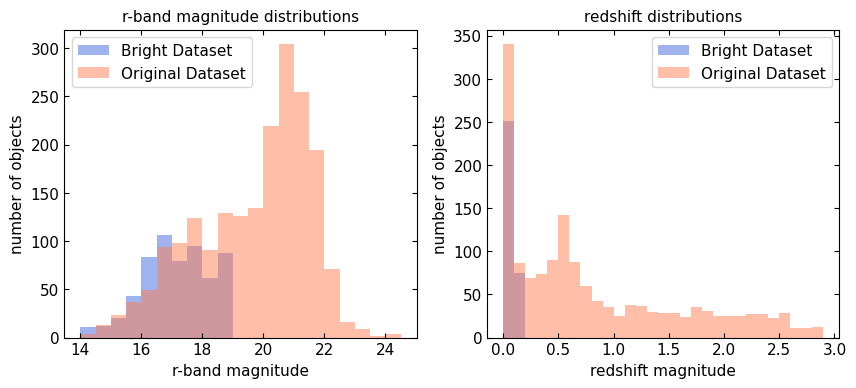

In [182]:
# Task 2.2: Your code here
fig, axes = plt.subplots(1,2,figsize=(10,4))
rbins = np.arange(14, 25, 0.5)

axes[0].hist(df_bright_sdss['r'], bins=rbins,color='royalblue',alpha=0.5,label='Bright Dataset')
axes[0].hist(df_sdss['r'], bins=rbins,color='coral',alpha=0.5,label='Original Dataset')
axes[0].set_xlabel('r-band magnitude')
axes[0].set_ylabel('number of objects')
axes[0].set_title('r-band magnitude distributions')
axes[0].legend()

redbins = np.arange(0, 3, 0.1)
axes[1].hist(df_bright_sdss['redshift'], bins=redbins,color='royalblue',alpha=0.5,label='Bright Dataset')
axes[1].hist(df_sdss['redshift'], bins=redbins,color='coral',alpha=0.5,label='Original Dataset')
axes[1].set_xlabel('redshift magnitude')
axes[1].set_ylabel('number of objects')
axes[1].set_title('redshift distributions')
axes[1].legend()

*Your discussion here (2-3 sentences): How do the samples differ? Why?*

The original data set is spread out over a larger range of magnitudes. Filtering the data for the brighter objects narrows the range that the objects will cover, and will shift them between specific values. The r-band magnitude distributions show how the bright objects were left shifted to a certain range, and additionally, since closer objects tend to be brighter, the redshift distributions show how the closer objects, with less of a redshift, would be much more abundant in a dataset of bright objects.

**Task 2.3 (3 pts):** Prepare the **original** `sdss_sample.csv` data for classification. Extract the 6 numerical features (`u`, `g`, `r`, `i`, `z`, `redshift`), **standardize** with `StandardScaler`, and split into train/test sets.

```python
def prepare_and_scale(
    df: pd.DataFrame,
    test_size: float = 0.3,
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Extract features, standardize, and split into train/test sets.

    Parameters
    ----------
    df : pd.DataFrame
        SDSS dataset with columns u, g, r, i, z, redshift, object_class.
    test_size : float
        Fraction of data for the test set.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        X_train_scaled, X_test_scaled, y_train, y_test.
    """
    ...
```

*Remember*: fit the scaler on the training set only, then transform both train and test.

In [183]:
# Task 2.3: Your code here
def prepare_and_scale(
    df: pd.DataFrame,
    test_size: float = 0.3,
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Extract features, standardize, and split into train/test sets.

    Parameters
    ----------
    df : pd.DataFrame
        SDSS dataset with columns u, g, r, i, z, redshift, object_class.
    test_size : float
        Fraction of data for the test set.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        X_train_scaled, X_test_scaled, y_train, y_test.
    """

    feature_cols = ['u','g','r','i','z','redshift']
    X = df[feature_cols].values
    y = df['object_class'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

---

## Part 3: Neural Network Classification (12 pts)

**Task 3.1 (4 pts):** Train an `MLPClassifier` with `hidden_layer_sizes=(64, 32)`, `max_iter=500`, and `random_state=42` on the scaled training data. Print both the **training accuracy** and **test accuracy**.

```python
from sklearn.neural_network import MLPClassifier
```

In [184]:
# Task 3.1: Your code here
from sklearn.neural_network import MLPClassifier

df_sdss = load_sdss()

X_train, X_test, y_train, y_test = prepare_and_scale(df_sdss)

MLP = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
MLP.fit(X_train, y_train)
y_pred_MLP = MLP.predict(X_test)

acc_train_MLP = accuracy_score(y_train, MLP.predict(X_train))
print(f"MLP Classifier Training Accuracy: {acc_train_MLP:.3f}")

acc_MLP = accuracy_score(y_test, y_pred_MLP)
print(f"MLP Classifier Test Accuracy: {acc_MLP:.3f}")

MLP Classifier Training Accuracy: 0.967
MLP Classifier Test Accuracy: 0.955


**Task 3.2 (4 pts):** Plot the **training loss curve** using `model.loss_curve_` (a list of loss values at each iteration). Create a single plot (`figsize=(6, 4)`) with labeled axes.

In a markdown cell, discuss (2-3 sentences): Does the loss converge? Does it converge smoothly or with oscillations? What might cause oscillations in the loss curve?

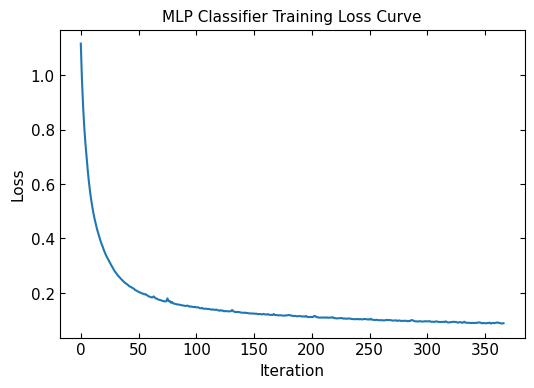

In [185]:
# Task 3.2: Your code here
plt.figure(figsize=(6,4))
plt.plot(MLP.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title("MLP Classifier Training Loss Curve")
plt.show()

*Your discussion here (2-3 sentences): Does the loss converge? Smooth or oscillating? Why?*

The loss curve drops off quickly then starts to plateau. There are some minor fluctuations as the line converges but the trend shows the initial drop off and then flattening with no major oscillations. The line isn't perfectly flat, so it could improve with more training, but in general it does converge smoothly.

**Task 3.3 (4 pts):** Compute and plot the **confusion matrix** as a heatmap (`figsize=(6, 5)`) using `viridis` colormap. Label axes with the three class names (STAR, GALAXY, QSO). Add numeric annotations in each cell.

In a markdown cell, discuss (2-3 sentences): Which class is hardest to classify correctly? Why might that be, physically? (*Hint*: think about what makes quasars photometrically similar to stars in some filters.)

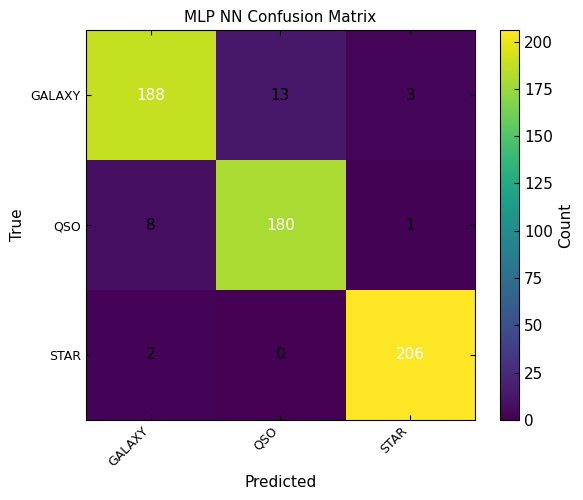

In [186]:
# Task 3.3: Your code here

cm = confusion_matrix(y_test, y_pred_MLP)
n = len(MLP.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='viridis')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(MLP.classes_, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(MLP.classes_, fontsize=9)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('MLP NN Confusion Matrix')
# Numeric annotations
for i in range(n):
    for j in range(n):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color)
plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

*Your discussion here (2-3 sentences): Which class is hardest? Why physically?*

The hardest class is quasars which were mistaken the most for galaxies. Physically, galaxies and quasars are outside of our galaxy and can have similar values for redshift and color making them difficult to separate using just photometric properties. Stars, being within our galaxy, have much different and unique properties making them easier to classify.

---

## Part 4: Hyperparameters & Comparison to HW5 Methods (14 pts)

**Task 4.1 (4 pts):** Compare at least 3 different neural network architectures by varying `hidden_layer_sizes`. Suggestions:

- Small: `(32,)` — one hidden layer, 32 neurons
- Medium: `(64, 32)` — two hidden layers
- Large: `(128, 64, 32)` — three hidden layers

Train each on the same data. Create a **bar chart** of test accuracies.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Small MLP Test Accuracy: 0.960
Medium MLP Test Accuracy: 0.955
Large MLP Test Accuracy: 0.953


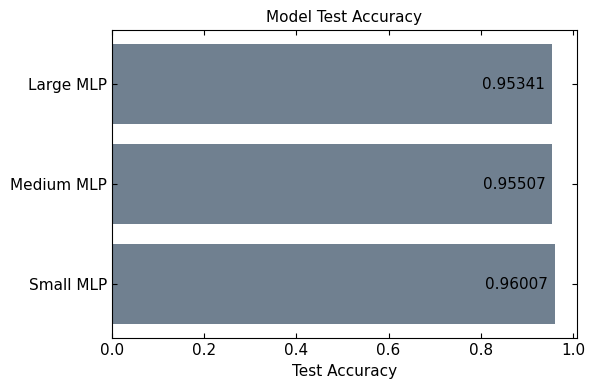

In [187]:
# Task 4.1: Your code here
from sklearn.neural_network import MLPClassifier
df_sdss = load_sdss()
X_train, X_test, y_train, y_test = prepare_and_scale(df_sdss)

#small classifier, (32,)
MLP_small = MLPClassifier(hidden_layer_sizes=(32, ), max_iter=500, random_state=42)
MLP_small.fit(X_train, y_train)
y_pred_MLP_small = MLP_small.predict(X_test)
acc_MLP_small = accuracy_score(y_test, y_pred_MLP_small)
print(f"Small MLP Test Accuracy: {acc_MLP_small:.3f}")

#medium classifier (64,32)
MLP_medium = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
MLP_medium.fit(X_train, y_train)
y_pred_MLP_medium = MLP_medium.predict(X_test)
acc_MLP_medium = accuracy_score(y_test, y_pred_MLP_medium)
print(f"Medium MLP Test Accuracy: {acc_MLP_medium:.3f}")

#large classifier (128, 64,32)
MLP_large = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)
MLP_large.fit(X_train, y_train)
y_pred_MLP_large = MLP_large.predict(X_test)
acc_MLP_large = accuracy_score(y_test, y_pred_MLP_large)
print(f"Large MLP Test Accuracy: {acc_MLP_large:.3f}")

#plot
accuracies = [acc_MLP_small, acc_MLP_medium, acc_MLP_large]
models = ["Small MLP", "Medium MLP", "Large MLP"]

fig, ax = plt.subplots(figsize=(6,4))
y_pos = range(len(models))
ax.barh(y_pos, accuracies, color='slategrey')
ax.set_yticks(y_pos)
ax.set_yticklabels(models)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Test Accuracy')

for i, v in enumerate(accuracies):
    ax.text(v-0.15, i, f"{v:.5f}", va='center', ha='left')

plt.show()


**Task 4.2 (5 pts):** Now compare the neural network to the classifiers from HW5. Train the following on the **same scaled SDSS data** (same train/test split):

- `DecisionTreeClassifier(random_state=42)`
- `KNeighborsClassifier(n_neighbors=5)` (on scaled data)
- `RandomForestClassifier(n_estimators=100, random_state=42)`
- Your best `MLPClassifier` from Task 4.1

Create a **bar chart** (`figsize=(6, 4)`) comparing all four test accuracies.

In a markdown cell, discuss (3-4 sentences): Does the neural network outperform the traditional classifiers? By how much? Given the size and nature of this dataset, is a neural network the best tool for this job? Why or why not?

Decision Tree Test Accuracy: 0.942
KNeighbors Test Accuracy: 0.905
Random Forest Test Accuracy: 0.960
Large MLP Test Accuracy: 0.953


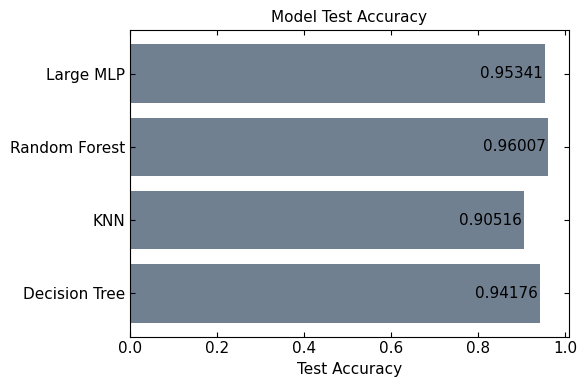

In [188]:
# Task 4.2: Your code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

df_sdss = load_sdss()
X_train, X_test, y_train, y_test = prepare_and_scale(df_sdss)

#Decision Tree Classifier
DTC = DecisionTreeClassifier(random_state=42)
DTC.fit(X_train, y_train)
y_pred_dtc = DTC.predict(X_test)
acc_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"Decision Tree Test Accuracy: {acc_dtc:.3f}")

#KNNeighbors Classifier
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_train, y_train)
y_pred_knn = KNN.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNeighbors Test Accuracy: {acc_knn:.3f}")

#Random Forest Classifier
RFC = RandomForestClassifier(n_estimators=100, random_state=42)
RFC.fit(X_train, y_train)
y_pred_rfc = RFC.predict(X_test)
acc_rfc = accuracy_score(y_test, y_pred_rfc)
print(f"Random Forest Test Accuracy: {acc_rfc:.3f}")

#large MLP Classifier
MLP_large = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)
MLP_large.fit(X_train, y_train)
y_pred_MLP_large = MLP_large.predict(X_test)
acc_MLP_large = accuracy_score(y_test, y_pred_MLP_large)
print(f"Large MLP Test Accuracy: {acc_MLP_large:.3f}")

#plot
fig, ax = plt.subplots(figsize=(6, 4))
models = ['Decision Tree', 'KNN', 'Random Forest', 'Large MLP']
y_pos = range(len(models))
accuracies = [acc_dtc, acc_knn, acc_rfc, acc_MLP_large]
ax.barh(y_pos, accuracies, color='slategrey')
ax.set_yticks(y_pos)
ax.set_yticklabels(models)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Test Accuracy')
for i, v in enumerate(accuracies):
    ax.text(v-0.15, i, f"{v:.5f}", va='center', ha='left')
plt.tight_layout()
plt.show()

*Your discussion here (3-4 sentences): Does the NN outperform? Is it the best tool for this dataset? Why?*

The NN outperforms the decision tree and k-nearest neighbor classifiers, but does not outperform the random forest. One reason for this could be the amount of data. A large NN requires a lot of data to be trained to its best ability, and there may not be enough data to fully train a large one. The random forest classifier is well suited for smaller datasets.

**Task 4.3 (5 pts):** Pick the **best neural network** and the **best traditional classifier** from Task 4.2. Create a **2-panel figure** (`figsize=(12, 5)`) showing their confusion matrices side by side. Use `viridis` colormap and numeric annotations.

In a markdown cell, discuss (3-4 sentences): Do the two classifiers make different kinds of mistakes? Which classes benefit most from the neural network? Are there classes where the traditional classifier does equally well or better?

Random Forest Test Accuracy: 0.960
Large MLP Test Accuracy: 0.953


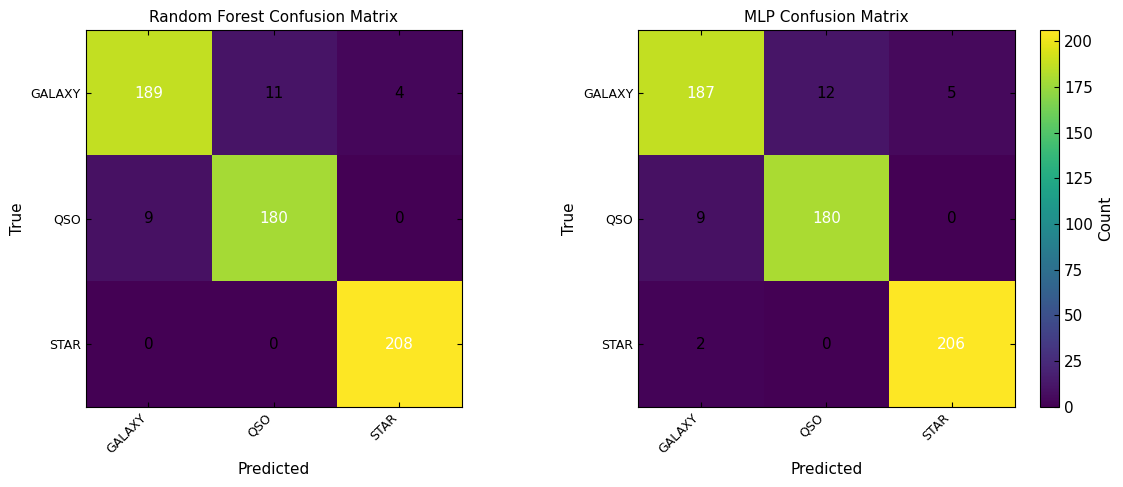

In [190]:
# Task 4.3: Your code here

# Random Forest Classifier
RFC = RandomForestClassifier(n_estimators=100, random_state=42)
RFC.fit(X_train, y_train)
y_pred_rfc = RFC.predict(X_test)
acc_rfc = accuracy_score(y_test, y_pred_rfc)
print(f"Random Forest Test Accuracy: {acc_rfc:.3f}")

#Large MLP Classifier
MLP_large = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)
MLP_large.fit(X_train, y_train)
y_pred_MLP_large = MLP_large.predict(X_test)
acc_MLP_large = accuracy_score(y_test, y_pred_MLP_large)
print(f"Large MLP Test Accuracy: {acc_MLP_large:.3f}")

RFCcm = confusion_matrix(y_test, y_pred_rfc)
MLPcm = confusion_matrix(y_test, y_pred_MLP_large)
n = len(MLP_large.classes_)

#Random Forest CM
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(RFCcm, cmap='viridis')
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(n))
axes[0].set_xticklabels(MLP_large.classes_, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(MLP_large.classes_, fontsize=9)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Random Forest Confusion Matrix')
# Numeric annotations
for i in range(n):
    for j in range(n):
        color = 'white' if RFCcm[i, j] > RFCcm.max() / 2 else 'black'
        axes[0].text(j, i, str(RFCcm[i, j]), ha='center', va='center', color=color)

#MPL CM
im = axes[1].imshow(MLPcm, cmap='viridis')
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels(MLP_large.classes_, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(MLP_large.classes_, fontsize=9)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('MLP Confusion Matrix')
# Numeric annotations
for i in range(n):
    for j in range(n):
        color = 'white' if MLPcm[i, j] > MLPcm.max() / 2 else 'black'
        axes[1].text(j, i, str(MLPcm[i, j]), ha='center', va='center', color=color)

plt.colorbar(im, label='Count')
plt.tight_layout()
plt.show()


*Your discussion here (3-4 sentences): Different mistakes? Which classes benefit from the NN?*

The two models are making the same kinds of mistakes, having difficulties separating quasars from galaxies. The Random Forest Classifier is slightly better, correctly predicting 1 more galaxy, but both models showed the least difficulties in classifying stars, and having some issues with the other two.

---

## Submission: Fork Workflow & PR

### Commit Your Work

**Using VS Code (recommended):**
1. Open the **Source Control** panel (branch icon in the left sidebar, or <kbd>Ctrl</kbd>+<kbd>Shift</kbd>+<kbd>G</kbd>)
2. Review your changes — files appear under "Changes"
3. Click the **+** next to each file to stage it (or **+** next to "Changes" to stage all)
4. Type a descriptive commit message in the text box
5. Click the **✓ Commit** button
6. Click **Sync Changes** (or the cloud upload icon) to push to your fork

**Using the terminal:**
```bash
git add 2026/HW/yourname/HW6.ipynb
git commit -m "Train MLPClassifier on SDSS photometric data"
git push origin yourname-hw6
```

**Good commit messages:**
- `Train MLPClassifier on SDSS data and plot loss curve`
- `Query SDSS for bright sample and compare to original dataset`
- `Compare neural network to Decision Tree and Random Forest`

**Bad commit messages:** `update`, `fix`, `stuff`, `done`

### Open a Pull Request

1. Go to `github.com/yourname/PHY386`
2. Click **"Compare & pull request"**
3. **Important**: Set base repository to `ubsuny/PHY386` and base branch to `Homework2026`
4. Title: `HW6 - 2026 - yourusername`
5. Fill out the PR template:
   - Add label: `homework-in-progress` or `homework-final`
   - Assign reviewer: `@laserlab`
   - Set milestone: `HW6-2026`

### Checklist

- [x] Forked the repository and synced with upstream
- [x] Created branch `yourname-hw6` from `Homework2026`
- [x] Completed Part 1 (data exploration + scatter plots)
- [x] Completed Part 2 (astroquery fetch + histogram comparison + data preparation)
- [x] Completed Part 3 (MLP training + loss curve + confusion matrix)
- [x] Completed Part 4 (architecture comparison + HW5 methods comparison + discussion)
- [x] All functions have **type annotations** and **NumPy-style docstrings**
- [x] All plots have labeled axes with filter names or units
- [x] All commit messages are descriptive
- [x] PR opened with correct title, label, reviewer, and milestone

## Resources

- [astroquery SDSS documentation](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html)
- [SDSS SkyServer SQL Tutorial](https://skyserver.sdss.org/dr18/Support/realquery)
- [SDSS Schema Browser (table/column definitions)](https://skyserver.sdss.org/dr18/en/help/browser/browser.aspx)
- [scikit-learn MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- [scikit-learn Neural Network Guide](https://scikit-learn.org/stable/modules/neural_networks_supervised.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [Sloan Digital Sky Survey (SDSS)](https://www.sdss.org/)
- [Multi-Layer Perceptron — Wikipedia](https://en.wikipedia.org/wiki/Multilayer_perceptron)
- [Backpropagation — Wikipedia](https://en.wikipedia.org/wiki/Backpropagation)
- [GitHub Codespaces Documentation](https://docs.github.com/en/codespaces)
- [GitHub Forking Workflow](https://docs.github.com/en/pull-requests/collaborating-with-pull-requests/working-with-forks)